# Input Generation — Kassel Weather: Hourly Air Temperature (MERRA-2, 2019)

## Purpose

This notebook processes the **hourly 2m air temperature series** for Kassel, Germany, which feeds the heat pump (HP) electricity demand pipeline. The cleaned CSV exported here is read directly by notebook `05_hp_demand_kassel_hz2_4500kwh_2026.ipynb`.

**Raw input file:** `raw-data/renewablesninja_weather_kassel_merra2_2019_retrieved_2026-02.csv`  
**Output file:** `inputs/weather_kassel_t2m_2019_hourly.csv`

## Data source

Temperature data is sourced from *renewables.ninja*:

> Renewables.ninja. (n.d.). *Renewables.ninja*. Retrieved February 2026, from https://www.renewables.ninja/

## Configuration

| Parameter | Value |
|---|---|
| Location | Kassel, Germany (51.32°N, 9.50°E) |
| Variable | 2m air temperature (`t2m`, °C) |
| Weather dataset | MERRA-2 global reanalysis |
| Reference year | 2019 |
| Output unit | °C (hourly) |

## Thesis reference

Chapter 3, Section 3.5.3 — *HP Profile (HZ2)*

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Path configuration ─────────────────────────────────────────────────────────
def find_repo_root(marker='README.md'):
    p = Path(os.getcwd()).resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise RuntimeError(f'Repo root not found (looked for: {marker})')

REPO_ROOT  = find_repo_root()
RAW_DATA   = REPO_ROOT / 'data' / 'raw'
INPUTS     = REPO_ROOT / 'inputs'
INPUTS.mkdir(parents=True, exist_ok=True)

RAW_PATH   = RAW_DATA / 'renewablesninja_weather_kassel_merra2_2019_retrieved_2026-02.csv'
OUTPUT_CSV = INPUTS   / 'weather_kassel_t2m_2019_hourly.csv'

assert RAW_PATH.exists(), f'Raw file not found: {RAW_PATH}'
print(f'Raw source : {RAW_PATH.name}')
print(f'Output     : {OUTPUT_CSV}')

Raw source : renewablesninja_weather_kassel_merra2_2019_retrieved_2026-02.csv
Output     : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/inputs/weather_kassel_t2m_2019_hourly.csv


## Step 1 — Load hourly temperature data

In [3]:
# Lines beginning with '#' are metadata comments from the renewables.ninja export.
# The series is indexed on local_time (Europe/Paris = CET/CEST) to align with the
# local-clock convention used throughout the thesis simulation pipeline.
df_raw = pd.read_csv(RAW_PATH, comment='#')
df_raw['local_time'] = pd.to_datetime(df_raw['local_time'])
df_raw = df_raw.set_index('local_time').sort_index()

t2m = df_raw['t2m']   # hourly air temperature in °C

print(f'Hours loaded  : {len(t2m):,}')
print(f'Date range    : {t2m.index.min()}  ->  {t2m.index.max()}')
print(f'Mean temp     : {t2m.mean():.2f} °C')
print(f'Min  temp     : {t2m.min():.2f} °C')
print(f'Max  temp     : {t2m.max():.2f} °C')

Hours loaded  : 8,760
Date range    : 2019-01-01 01:00:00  ->  2020-01-01 00:00:00
Mean temp     : 9.64 °C
Min  temp     : -9.04 °C
Max  temp     : 36.85 °C


## Step 2 — Visualisation

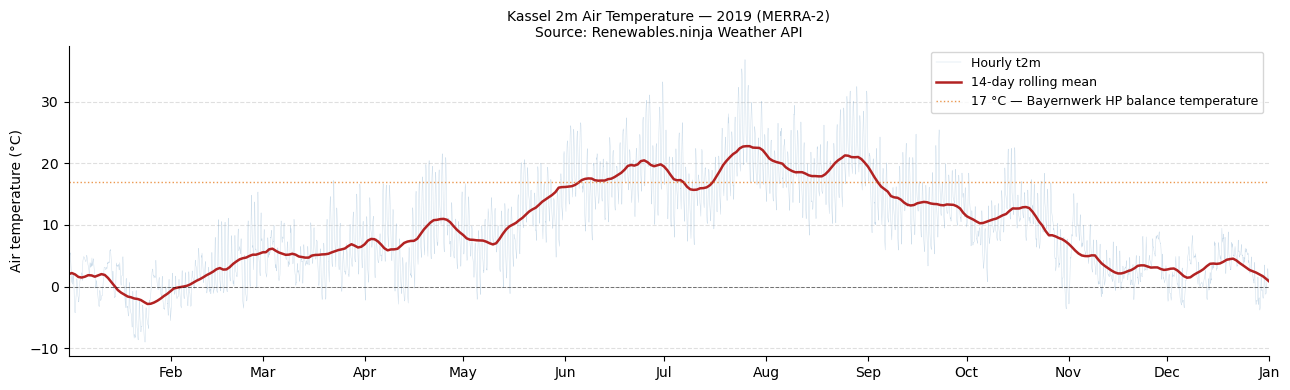

In [4]:
daily   = t2m.resample('D').mean()
rolling = daily.rolling(window=14, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(t2m.index, t2m.values, lw=0.3, alpha=0.3, color='steelblue', label='Hourly t2m')
ax.plot(rolling.index, rolling.values, lw=1.8, color='firebrick', label='14-day rolling mean')
ax.axhline(0, color='black', lw=0.7, ls='--', alpha=0.5)
ax.axhline(17, color='#e67e22', lw=1.0, ls=':', alpha=0.8,
           label='17 °C — Bayernwerk HP balance temperature')

ax.set_ylabel('Air temperature (°C)')
ax.set_title(
    'Kassel 2m Air Temperature — 2019 (MERRA-2)\n'
    'Source: Renewables.ninja Weather API',
    fontsize=10
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlim(t2m.index[0], t2m.index[-1])
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## Step 3 — Summary statistics

In [5]:
daily_mean = t2m.resample('D').mean()

print('Kassel 2m Temperature (MERRA-2 2019) — Summary')
print('-' * 50)
print(f'  Annual mean            : {t2m.mean():.2f} °C')
print(f'  Annual min             : {t2m.min():.2f} °C')
print(f'  Annual max             : {t2m.max():.2f} °C')
print(f'  Daily mean: min/max    : {daily_mean.min():.2f} / {daily_mean.max():.2f} °C')
print('-' * 50)

Kassel 2m Temperature (MERRA-2 2019) — Summary
--------------------------------------------------
  Annual mean            : 9.64 °C
  Annual min             : -9.04 °C
  Annual max             : 36.85 °C
  Daily mean: min/max    : -6.38 / 28.80 °C
--------------------------------------------------


## Step 4 — Export to CSV

In [6]:
df_out = pd.DataFrame({
    'local_time' : t2m.index.strftime('%Y-%m-%d %H:%M'),
    't2m_celsius': t2m.values.round(6),
})

df_out.to_csv(OUTPUT_CSV, index=False)

print(f'Exported : {OUTPUT_CSV}')
print(f'Shape    : {df_out.shape}')
print()
print(df_out.head(6).to_string(index=False))

Exported : /Users/juliusrucha/Library/CloudStorage/GoogleDrive-rucha.julius@gmail.com/Meine Ablage/Master_Thesis_2026/07_Thesis_GitHub/inputs/weather_kassel_t2m_2019_hourly.csv
Shape    : (8760, 2)

      local_time  t2m_celsius
2019-01-01 01:00        5.638
2019-01-01 02:00        5.554
2019-01-01 03:00        5.482
2019-01-01 04:00        5.343
2019-01-01 05:00        5.108
2019-01-01 06:00        4.878
